In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
df = pd.read_csv("D:\\datafile\\retail_shop_data.csv")
df.head()

,Date,Customer ID,Product ID,Product Name,Cost,Price,Quantity,Total
0,1 01 2023,1001,101,T-Shirt,18,20,2,40
1,1 01 2023,1002,102,Jeans,35,50,1,50
2,2 01 2023,1003,103,Hoodie,25,30,3,90
3,3 01 2023,1004,104,Sneakers,55,70,2,140
4,3 01 2023,1005,105,Sunglasses,17,25,1,25


In [17]:
df.dtypes

Date            object
Customer ID      int64
Product ID       int64
Product Name    object
Cost             int64
Price            int64
Quantity         int64
Total            int64
dtype: object

In [18]:
df.shape

(21, 8)

shape[0] - number of rows and shape[1] - number of column

In [19]:
df.shape[0]

21

In [20]:
df.shape[1]

8

In [21]:
df.duplicated('Product Name').sum()

np.int64(1)

In [22]:
df2 = df.copy()
df2.rename(columns = {'Total': 'Revenue','Cost': 'Cost Per Product', 'Price': 'Price per product'}, inplace = True)
df2.head()

,Date,Customer ID,Product ID,Product Name,Cost Per Product,Price per product,Quantity,Revenue
0,1 01 2023,1001,101,T-Shirt,18,20,2,40
1,1 01 2023,1002,102,Jeans,35,50,1,50
2,2 01 2023,1003,103,Hoodie,25,30,3,90
3,3 01 2023,1004,104,Sneakers,55,70,2,140
4,3 01 2023,1005,105,Sunglasses,17,25,1,25


In [23]:
df2['Costs'] = df2['Cost Per Product'] * df2['Quantity']
df2.head()

,Date,Customer ID,Product ID,Product Name,Cost Per Product,Price per product,Quantity,Revenue,Costs
0,1 01 2023,1001,101,T-Shirt,18,20,2,40,36
1,1 01 2023,1002,102,Jeans,35,50,1,50,35
2,2 01 2023,1003,103,Hoodie,25,30,3,90,75
3,3 01 2023,1004,104,Sneakers,55,70,2,140,110
4,3 01 2023,1005,105,Sunglasses,17,25,1,25,17


In [24]:
df2['Profit'] = df2['Revenue'] - df2['Costs']
df2.head()

,Date,Customer ID,Product ID,Product Name,Cost Per Product,Price per product,Quantity,Revenue,Costs,Profit
0,1 01 2023,1001,101,T-Shirt,18,20,2,40,36,4
1,1 01 2023,1002,102,Jeans,35,50,1,50,35,15
2,2 01 2023,1003,103,Hoodie,25,30,3,90,75,15
3,3 01 2023,1004,104,Sneakers,55,70,2,140,110,30
4,3 01 2023,1005,105,Sunglasses,17,25,1,25,17,8


In [25]:
df2['Filter'] = df2['Profit'] > 15
df2.head()

,Date,Customer ID,Product ID,Product Name,Cost Per Product,Price per product,Quantity,Revenue,Costs,Profit,Filter
0,1 01 2023,1001,101,T-Shirt,18,20,2,40,36,4,False
1,1 01 2023,1002,102,Jeans,35,50,1,50,35,15,False
2,2 01 2023,1003,103,Hoodie,25,30,3,90,75,15,False
3,3 01 2023,1004,104,Sneakers,55,70,2,140,110,30,True
4,3 01 2023,1005,105,Sunglasses,17,25,1,25,17,8,False


In [26]:
df2.query("Filter == True")['Product Name']
                           

3     Sneakers
7       Jacket
13      Jacket
Name: Product Name, dtype: object

In [27]:
df2.sort_values('Profit', inplace = True)
cost_diff = df.iloc[-1]["Costs"] - df.iloc[0]["Costs"]
print('The cost difference between most and least profitable product is', cost_diff)

KeyError: 'Costs'

In [ ]:
df_data = df2.groupby("Product Name")["Costs"].sum()
cost_of_jacket = df_data.loc['Jacket']

print("The cost of Jacket is", cost_of_jacket)    

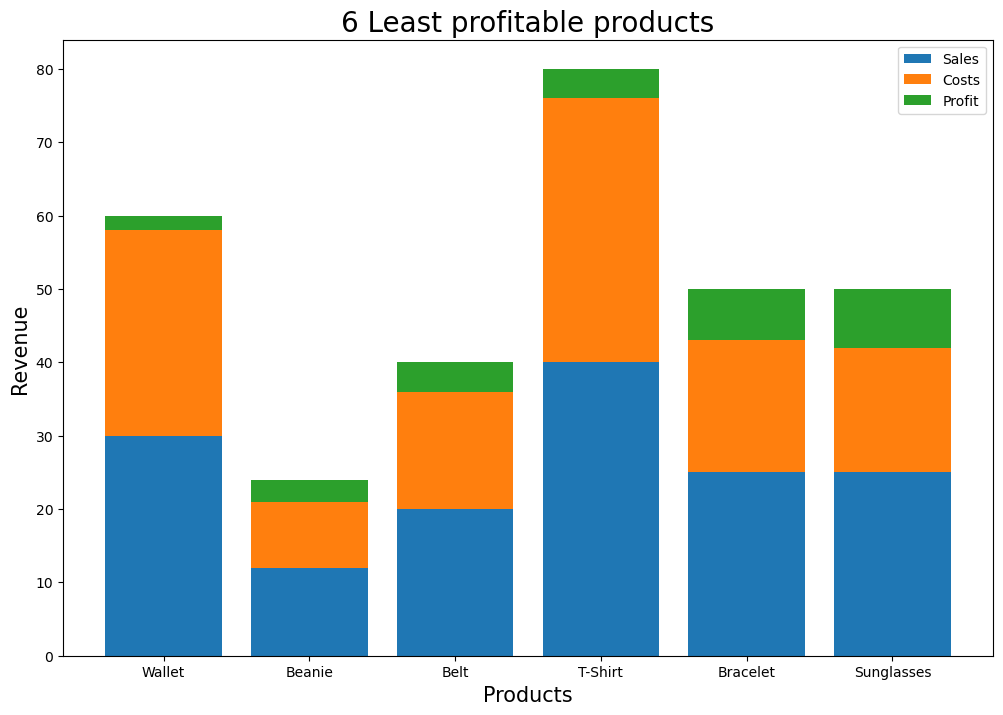

In [28]:
import matplotlib.pyplot as plt


df_least_5_products = df2.sort_values(by = "Profit", ascending = True)[0:6]

#Create data
products = df_least_5_products["Product Name"]
sales = df_least_5_products["Revenue"]
Costs = df_least_5_products["Costs"]
profit = df_least_5_products["Profit"]

fig, ax = plt.subplots(figsize=(12, 8))

#plotting the data
ax.bar(products, sales, label="Sales")
ax.bar(products, Costs, label ="Costs", bottom = sales)
ax.bar(products, profit, label="Profit", bottom = sales+Costs)


ax.set_ylabel("Revenue", fontsize = 15)
ax.set_xlabel("Products", fontsize = 15)
plt.xticks(rotation = 0)
ax.legend()
plt.title("6 Least profitable products", fontsize = 20)
plt.show()




In [34]:
df2.head()

,Date,Customer ID,Product ID,Product Name,Cost Per Product,Price per product,Quantity,Revenue,Costs,Profit,Filter
16,11 01 2023,1006,116,Wallet,28,30,1,30,28,2,False
12,9 01 2023,1003,113,Beanie,9,12,1,12,9,3,False
15,10 01 2023,1005,115,Belt,16,20,1,20,16,4,False
0,1 01 2023,1001,101,T-Shirt,18,20,2,40,36,4,False
18,13 01 2023,1008,118,Bracelet,18,25,1,25,18,7,False


In [35]:
sales_sunglass = df2.loc[df2["Product Name"] == "Sunglasses", "Revenue"]
print(sales_sunglass)

4    25
Name: Revenue, dtype: int64


In [36]:
costs_sunglass = df2.loc[df2["Product Name"] == "Sunglasses", "Costs"]
print(costs_sunglass)

4    17
Name: Costs, dtype: int64


In [42]:
profit_of_sunglass = sales_sunglass - costs_sunglass
print(f" Profit in sunglass is {profit_of_sunglass.iloc[0]} dollars")

 Profit in sunglass is 8 dollars


In [48]:
profit_of_Sun = df2.loc[df2["Product Name"] == "Sunglasses", "Profit"]
print(f" Profit of Sunglasses {profit_of_Sun.iloc[0]} dollars")

 Profit of Sunglasses 8 dollars


In [49]:
profit_hoodies = df2.loc[df2["Product Name"] == "Hoodie", "Profit"]
print(f" Profit of Hoodie {profit_hoodies.iloc[0]} dollars")

 Profit of Hoodie 15 dollars


In [52]:
df2.sort_values("Profit", inplace = True)
least_profitable_products = df2.iloc[:2, 3]
least_profitable_products

16    Wallet
12    Beanie
Name: Product Name, dtype: object

In [56]:
df_most_profit = df2.loc[df2["Profit"] == max(df2["Profit"])]
df_most_profit[['Product ID', 'Product Name']]

,Product ID,Product Name
16,116,Wallet
12,113,Beanie
15,115,Belt
0,101,T-Shirt
18,118,Bracelet
4,105,Sunglasses
11,112,Leggings
5,106,Backpack
6,107,Watch
17,117,Earrings
